## Dados estruturados

Nos últimos 20 anos, um grande foco tem sido dado a __Big Data__.

Fontes de dados que podem gerar grandes volumes de informação _estruturadas_ ou _não estruturadas_.

Uma imagem, por exemplo, pode ser considerada uma grande coleção de pixels (RGB se for colorida).

Um dos grandes desafios na ciência de dados é transformar dados crus em informação útil.

Ferramentas estatísticas, para serem aplicadas, precisam de dados _estruturados_ , como por exemplo em formato tabular.

Dados estruturados podem, a grosso modo, ser encaixados em duas categorias básicas:

 - Dados Numéricos. Podem vir em duas formas: números _contínuos_ e _discretos_.
 - Dados Categóricos. Que tem um conjunto fixo de valores possíveis. Ex: Tipo de display (LCD, LED, OLED).

Um subconjunto muito importante dos dados categóricos são os dados _ordinais_. Exemplo: Nota das críticas de um aparelho celular na Amazon (de 1 a 5). Por que ordinais são importantes?

#### Por que esta taxonomia é importante?

O tipo de dado vai definir as analises, predições, modelos, visualizações, etc.



## Dados tabulares

A forma mais usual de tratar dados é como tabelas, ou _data frames_.

Para manipular dataframes neste curso, usaremos uma das bibliotecas mais famosas para isto, o pandas.


In [1]:
!pip install scipy

In [2]:
import pandas as pd
from scipy import stats
import numpy as np
%matplotlib inline

df = pd.read_csv('state.csv')

df

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE
8,Florida,18801310,5.8,FL
9,Georgia,9687653,5.7,GA


### Dados não retangulares

Existem outros tipos de dados além dos tabulares quem podem ser muito úteis:

 - Séries temporais.
 - Dados espaciais.
 - Grafos.

## Entendendo melhor os seus dados.

Ao se encontrar com uma base de dados novas, é muito normal ficar perdido sem nem saber por onde começar. Portanto, é importante, antes de tudo, tentar __entender__ os dados. Especialmente agora que muito de machine learning é composto por caixas-pretas.

Antes de mais nada, é importante descobrir quais são os valores típicos de cada variável (coluna de uma tabela, também conhecida como _feature_ ou característica).

Qual seria a primeira forma de se estimar um valor típico?

Normalmente, a primeira escolha seria a _média_. Mas podemos ir além. Alguns termos importantes:

 - __Média__: Soma dos valores dividido pelo número de valores. (_mean_ ou _average_ )
 - __Média Ponderada__: Soma dos valores vezes um peso, dividida pela soma dos pesos. (_weighted average_ )
 - __Mediana__: Um valor em que uma metade dos dados está abaixo dele e a outra acima. (_median_ )
 - __Mediana Ponderada__:Um valor em que uma metade da soma dos $pesos * valores$ está abaixo dele e a outra acima. (_weighted median_ )
 - __Média Truncada__:A média de todos os valores após um número N de valores mais extremos ser removidos. (_Trimmed mean_ )
 - __Robusto__: Resistente à valores extremos.
 - __Outlier__: Valor muito diferente da maior parte dos dados.

 A primeira vista, resumir os dados parece trivial, basta ver a média. Contudo, muitas vezes a média não é a melhor métrica para diversas distribuições de dados.

 Formalizando:

### Media

 $$ \overline{x}=\frac{\sum_{i}^{n}{x_i}}{n}$$


### Média Truncada

 Dados os valores ordenados $x_{(1)},x_{(2)}...x_{(n)}$, onde $x_{(1)}$ é o menor valor e $x_{(n)}$ o maior, a média truncada é:

 $$ \overline{x}=\frac{\sum_{i+p}^{n-p}{x_{(i)}}}{n-2p} $$

 A média truncada elimina a influência dos valores mais extremos, e é muito utilizada em diversos contextos (até mesmo esportivos).


 ### Média Ponderada

 $$ \overline{x}=\frac{\sum_{i}^{n}{x_iw_i}}{\sum_{i}^{n}{w_i}} $$

 Média ponderada é útil em 2 cenários:
  - Alguns valores são intrinsecamente mais variáveis que outros, e queremos que estes mais ruidosos tenham um impacto menor. Ex: Temos diversos sensores, com um sendo menos preciso, podemos diminuir a importância das medições do mesmo
  - Dados coletados não representam corretamente diferentes grupos, então deve-se corrigir a média pela frequência real.
  
  
 ### Mediana

 A mediana é o número do meio dos dados ordenados (se tiver um número par de valores, a mediana é a média dos 2 no meio). Enquanto a média usa todos os valores, a mediana depende apenas do centro dos dados ordenados. Parece ruim, não? Ela é muito mais sensivel aos dados! Contudo, existem muitas situações onde ela é a melhor métrica. Vocês conseguem pensar em alguma?

### Outliers

A mediana é chamada de _métrica robusta_ pois não é influenciada por _outliers_ (casos extremos). A definição de outlier é subjetiva em muitos casos. Outliers por si só não invalida o dado, mas tem que se tomar cuidado. Além da mediana, a média truncada também é robusta. Inclusive, truncar valores nos 10% é uma tática comum para diminuir os impactos de outliers na maior parte dos conjuntos de dados.

## Exemplos:

In [3]:
df.Population = pd.to_numeric(df.Population)
df

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE
8,Florida,18801310,5.8,FL
9,Georgia,9687653,5.7,GA


In [4]:
df[['Population','Abbreviation']].sort_values(by=['Population'])

,Population,Abbreviation
49,563626,WY
44,625741,VT
33,672591,ND
1,710231,AK
40,814180,SD
7,897934,DE
25,989415,MT
38,1052567,RI
28,1316470,NH
18,1328361,ME


In [5]:
df.Population.mean()

np.float64(6162876.3)

In [6]:
stats.trim_mean(df.Population,0.1)

np.float64(4783697.125)

In [7]:
df.Population.median()

4436369.5

### Por que tivemos esta variação?


Agora vamos focar na taxa de homicídio. Vamos verificar como ela fica levando em conta a população:

In [8]:
np.average(df['Murder.Rate'],weights=df.Population)

np.float64(4.445833981123393)

E a mediana ponderada?

In [9]:
(df.Population*df['Murder.Rate']).median()

16266223.399999999

## Estimando Variabilidade

Medidas de localização de dados, como vistas acima, são apenas uma dimensão dos dados. Uma segunda dimensão, _variabilidade_ (ou _dispersão_ ) mede se os dados estão densamente agrupados ou espalhados. A variabilidade está no coração da estatística: medir, reduzir, distinguir aleatoriedade de variabilidade real , identificar as fontes de variabilidade e, principalmente, fazer decisões baseadas na sua presença.

### Terminologia

 - __Desvio__: Diferença entre o valor observado e a estimativa de localização (média,mediana, etc).
 - __Variância__: Medida que agrupa todos os desvios (também conhecido como _erro quadrado médio_ ).
 - __Desvio Padrão__: Raiz quadrada da variância (norma l2, norma euclidiana).
 - __Desvio médio absoluto__: A média dos desvios absolutos (norma l1 ou norma de Manhattan)
 - __Desvio mediano absoluto da mediana__: Mediana do valor absoluto do desvio da mediana
 - __Intervalo__: Diferença entre o maior e o menor valor.
 - __Estatísticas de ordem__: Métricas baseadas nos valores ordenados (_rank_ ).
 - __Percentil__: Um valor em que P%  dos valores são menores e (100-P)% são maiores (_quantil_ )
 - __Intervalo Interquartil__: Diferença entre o 75-percentil e o 25-percentil.

 ### Desvio Padrão

É a estimativa de variação mais usada. Exemplo: em um conjunto de dados $\{1,4,4\}$, a média é 3 e a mediana é 4. Os desvios da média são as diferenças $1-3=-2,4-3=1,4-3=1$. Eles mostram quão dispersos os valores são com relação ao valor central.

A média simples dos desvios não dizem muito (os desvios negativos cancelariam os positivos). Inclusive, a soma dos desvios _sempre_ será zero. Desta forma, uma alternativa é calcular a média dos valores absolutos dos desvios:

 $$ DesvioMedioAbsoluto=\frac{\sum_{i}^{n}{\vert x_i-\overline{x}} \vert}{n}$$

Mais comum é o uso de _variância_ e do _desvio padrão_ , que são baseados nos desvios quadrados:


$$ \sigma^2=\frac{\sum_{i}^{n}{ (x_i-\overline{x}})^2}{n}$$

$$ \sigma=\sqrt{\sigma^2}$$

Por que usar o desvio padrão e não a variância? Alguém tem alguma ideia?


Contudo, variância e desvio padrão ainda são médias de valores, e portanto sensíveis a outliers.

Uma métrica robusta de desvio é a mediana do desvio absoluto da mediana, ou MAD. Como vocês acham que é esta métrica?

Vamos ver como implementar agora:

In [10]:
df[['Murder.Rate','Population']].var()

,0
Murder.Rate,3.670045e+00
Population,4.689833e+13


In [11]:
df.Population.std()

6848235.347401142

In [12]:
stats.median_abs_deviation(df.Population)

np.float64(2596702.0)

## Estimativas baseadas em percentis

O pandas tem uma forma simples de visualizar os percentis:

In [14]:
df.describe()

,Population,Murder.Rate
count,5.000000e+01,50.000000
mean,6.162876e+06,4.066000
std,6.848235e+06,1.915736
min,5.636260e+05,0.900000
25%,1.833004e+06,2.425000
50%,4.436370e+06,4.000000
75%,6.680312e+06,5.550000
max,3.725396e+07,10.300000


O Intervalo Interquartil, ou IQR, é uma forma menos sensível a outliers de utilizar os percentis. Ela é a diferença entre o 75-percentil e o 25-percentil:

In [17]:
stats.iqr(df['Murder.Rate'])

np.float64(3.125)

## Explorando a distribuição dos dados

Cada estimativa que vimos até aqui resume os dados a um único número. Contudo, pode ser interessante explorar como os dados são distribuídos.

### Percentis usando boxplots

Percentis são muito comunmente utilizados. ~E comum mostrar os quartis (25%,50%,75%). Na cultura popular, é comum se referir aos 1%, que são os membros de 99 percentil de riqueza.

Uma forma interessante de visualizar quartis é através do uso de _boxplots_.

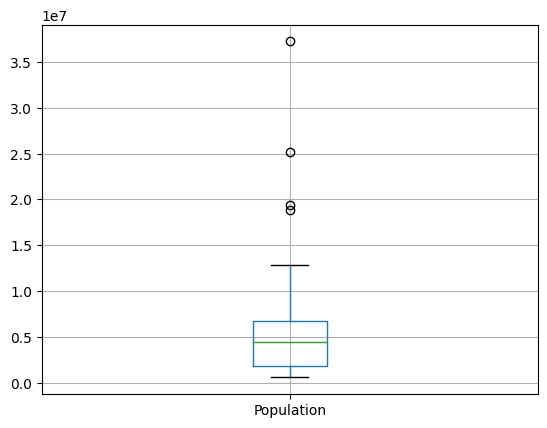

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
df.boxplot(column=['Population'])
plt.pause(1)

#violion plot é uma outra variacao pra ver

No boxplot, a caixa representa o IQR, a linha a mediana, e o intervalo fora da caixa representa um limite dos dados, onde quem está fora deste limite é considerado um outlier ($Q1 - 1.5.IQR$ e $Q3 + 1.5.IQR$)

### Tabela de frequências e Histogramas

Visualizar a distribuição de dados é muito importante para entendermos melhor como os mesmos se relacionam. Para isto, uma forma comum é usar tabelas agregadoras por frequência. Neste tipo de tabelas, os valores são agrupados em _bins_ do mesmo tamanho, e se conta quantos valores fazem parte de cada _bin_.

In [18]:
df.Population.value_counts(bins=10)

,count
"(526935.669, 4232659.0]",24
"(4232659.0, 7901692.0]",14
"(7901692.0, 11570725.0]",6
"(11570725.0, 15239758.0]",2
"(15239758.0, 18908791.0]",1
"(18908791.0, 22577824.0]",1
"(22577824.0, 26246857.0]",1
"(33584923.0, 37253956.0]",1
"(26246857.0, 29915890.0]",0
"(29915890.0, 33584923.0]",0


Para se visualizar melhor uma tabela de frequência, uma forma usual é o uso de histogramas, gráficos de barras em que o eixo X contém os bins (de tamanhos iguais) e o eixo y a frequência neste bin.

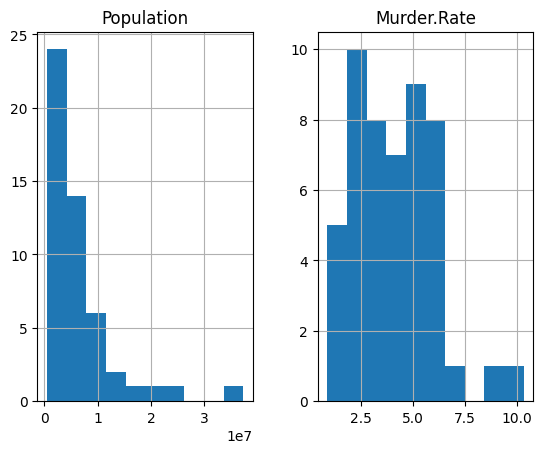

In [19]:
df.hist(bins=10)
plt.pause(1)

## Métricas de Densidade

Relacionado a histogramas, existem os plots de densidade, que mostram a distribuição dos valores como uma linha contínua. Pode-se imaginar o plot de densidade como uma espécie de interpolação do histograma. Diversas funções podem ser utilizadas para fazer esta "interpolação"

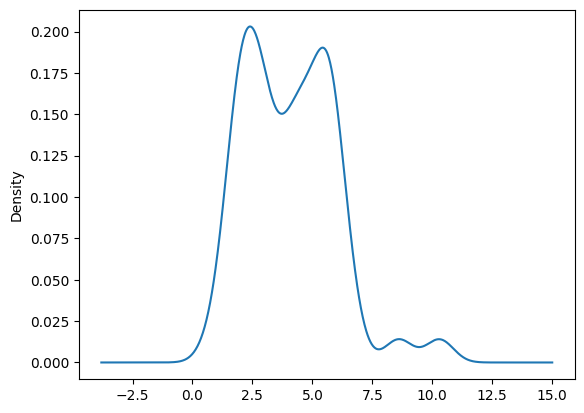

In [21]:
#df['Murder.Rate'].plot.kde()
df['Murder.Rate'].plot.kde(bw_method=0.3)
#df['Murder.Rate'].plot.kde(bw_method=3)
plt.pause(1)

#cuidado com metodos parametricos

#### Resumindo:

 - Histogramas de frequência mostra as frequências no eixo Y e  valores de variáveis no eixo X. Ele dá uma ideia da distribuição dos valores de forma intuitiva e visual.
 - Uma tabela de frequência é a versão tabular dos contadores de frequência de um histograma.
 - Um boxplot contém uma caixa com o primeiro e terceiro quartil (o IQR) e também ajua visualizar os dados, especialmente por mostrar os possíveis outliers.
 - Um plot de densidade é uma versão "linear" de um histograma, e pode usar uma entre várias funções para esta "interpolação".